In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
from scipy.integrate import quad, cumulative_trapezoid

In [3]:
energies = np.logspace(0, 4, 100)

In [4]:
filepath = "build/output/muon_track_0.txt"
df = pd.read_csv(filepath, sep=r'\s+', header=0, usecols=[1, 2, 4], 
                names=['x', 'y', 'rec_e'], dtype={'x': float, 'y': float, 'rec_e': float})
x_positions = df['x'].values.reshape(-1, 10)
y_positions = df['y'].values.reshape(-1, 10)
rec_energies = df['rec_e'].values.reshape(-1, 10)

In [9]:
dev = np.sqrt(x_positions**2 + y_positions**2)

sums = dev.sum(axis=0)

counts = (dev != 0).sum(axis=0)

survival = counts / 1000

avg_dev = np.divide(sums, counts, out=np.zeros_like(sums, dtype=float), where=counts!=0)

std_dev = np.sqrt(np.divide(((dev - avg_dev)**2).sum(axis=0), counts, out=np.zeros_like(sums, dtype=float), where=counts!=0))

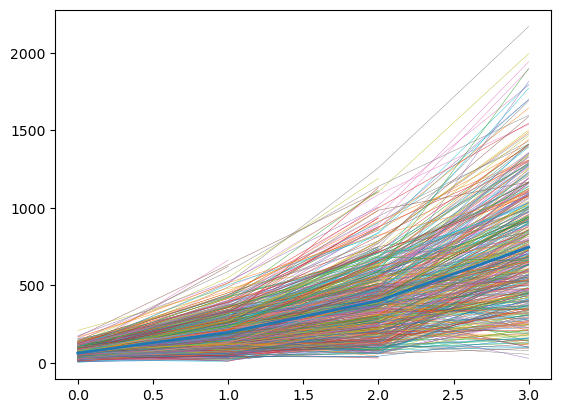

In [6]:
for dev_run in dev:
    plt.plot(dev_run[dev_run > 0], linewidth=0.3)

plt.plot(avg_dev[avg_dev > 0], linewidth=2)


In [10]:
size_m2 = 10
int_time = 600

In [ ]:
e, flux = np.loadtxt("H3a.txt", usecols=(0, 1), unpack=True)
flux_interp = interp1d(e, flux, kind='linear', fill_value="extrapolate")
integral_flux, _ = quad(flux_interp, 1, 10000)

In [22]:
flux_in_scenario = integral_flux * size_m2 * int_time * np.pi * 4

In [32]:
e_grid = np.logspace(0, 4, 100)

pdf = flux_interp(e_grid)
pdf = np.maximum(pdf, 0)

cdf = cumulative_trapezoid(pdf, e_grid, initial=0)

cdf_normalized = cdf / cdf[-1]


inv_cdf = interp1d(cdf_normalized, e_grid, bounds_error=False, fill_value=(e_grid[0], e_grid[-1]))

random_u = np.random.uniform(0, 1, int(flux_in_scenario))

sampled_energies = inv_cdf(random_u)

In [33]:
sampled_energies

array([34.40649279,  2.5276717 ,  3.88696787, ..., 19.93350168,
        3.80368826,  6.99919648], shape=(1207412,))